In [39]:
# haimtran 04/09/2023
# get performance insight for rds mysql 
# https://docs.aws.amazon.com/AmazonRDS/latest/UserGuide/USER_PerfInsights.UsingDashboard.Components.html#USER_PerfInsights.UsingDashboard.Components.AvgActiveSessions.dims


[Performance metrics for MySQL](https://docs.aws.amazon.com/AmazonRDS/latest/UserGuide/USER_PerfInsights.UsingDashboard.Components.html#USER_PerfInsights.UsingDashboard.Components.AvgActiveSessions.dims)

[Performance Insight API](https://docs.aws.amazon.com/performance-insights/latest/APIReference/API_GetResourceMetrics.html)

[Performance Insights MetricQuery](https://docs.aws.amazon.com/performance-insights/latest/APIReference/API_MetricQuery.html)


![pi-metrics-mysql](./assets/performance-insight-metrics-per-db-type.png)


> A single query to be processed. You must provide the metric to query and append an aggregate function to the metric. For example, to find the average for the metric db.load you must use db.load.avg. Valid values for aggregate functions include .avg, .min, .max, and .sum. If no other parameters are specified, Performance Insights returns all data points for the specified metric. Optionally, you can request that the data points be aggregated by dimension group (GroupBy), and return only those data points that match your criteria (Filter).

![performance-insight-load-test](./assets/performance-insights-load-test.png)

In [40]:
import boto3
import time 
import logging
from datetime import datetime
import matplotlib.pyplot as plt

In [41]:
# 2024/9/1/10/10
start_time = datetime(2024, 9, 1, 10, 10)
end_time = datetime(2024, 9, 1, 11, 10)

In [42]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [43]:
rds_client = boto3.client('rds', region_name='ap-southeast-1')
pi_client = boto3.client('pi', region_name='ap-southeast-1')

In [44]:
dbInstanceResponse = rds_client.describe_db_instances()

In [45]:
# get identifier of db instance with performance insights enabled
# and engine is mysql 
dbIds = [x['DbiResourceId'] for x in dbInstanceResponse['DBInstances'] if x['PerformanceInsightsEnabled']==True and x["Engine"]=='mysql']

In [46]:
# dbInstanceResponse["DBInstances"][1]

In [47]:
dbIds

['db-Y23W3CGTFBKS3H4YPMJEP6VV4A',
 'db-3CG72XHFTB3YPR36XL24Z55S6Y',
 'db-BHF4WHDOZT4XBDLSSY7CQOQPAE',
 'db-2LUCT6ZWBF5ANKDULZ7AYWWFCE']

In [48]:
dbSliceGroup = { "db.sql_tokenized", "db.wait_event", "db.user", "db.host", "db" }

In [49]:
# dbSliceGroup = { "db.wait_event" }

In [50]:
metric_queries = [
  {
    "Metric": "db.load.avg",
    "GroupBy": {
      "Group": group
    }
  }
for group in dbSliceGroup
]

In [51]:
metric_queries

[{'Metric': 'db.load.avg', 'GroupBy': {'Group': 'db'}},
 {'Metric': 'db.load.avg', 'GroupBy': {'Group': 'db.host'}},
 {'Metric': 'db.load.avg', 'GroupBy': {'Group': 'db.wait_event'}},
 {'Metric': 'db.load.avg', 'GroupBy': {'Group': 'db.user'}},
 {'Metric': 'db.load.avg', 'GroupBy': {'Group': 'db.sql_tokenized'}}]

In [52]:
dbId = dbIds[3]

In [53]:

response = pi_client.get_resource_metrics(
  ServiceType='RDS',
  Identifier=dbId,
  StartTime=start_time, 
  EndTime=end_time,
  PeriodInSeconds=60,
  MetricQueries=metric_queries
)

In [54]:
response

{'AlignedStartTime': datetime.datetime(2024, 9, 1, 10, 10, tzinfo=tzlocal()),
 'AlignedEndTime': datetime.datetime(2024, 9, 1, 11, 10, tzinfo=tzlocal()),
 'Identifier': 'db-2LUCT6ZWBF5ANKDULZ7AYWWFCE',
 'MetricList': [{'Key': {'Metric': 'db.load.avg'},
   'DataPoints': [{'Timestamp': datetime.datetime(2024, 9, 1, 10, 11, tzinfo=tzlocal()),
     'Value': 0.2},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 12, tzinfo=tzlocal()),
     'Value': 0.1},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 13, tzinfo=tzlocal()),
     'Value': 0.2833333333333333},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 14, tzinfo=tzlocal()),
     'Value': 0.35},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 15, tzinfo=tzlocal()),
     'Value': 0.43333333333333335},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 16, tzinfo=tzlocal()),
     'Value': 0.23333333333333334},
    {'Timestamp': datetime.datetime(2024, 9, 1, 10, 17, tzinfo=tzlocal()),
     'Value': 0.35},
    {'Timestamp': d

In [71]:
metric_by_dimension = []
for metric in response["MetricList"]:
  # get dimension
  dimension = metric["Key"].get("Dimensions")
  # dimension is not None 
  if (dimension != None):
    last_item = dimension.popitem() 
    name = {last_item[0]:last_item[1]}
    values = [x["Value"] for x in metric["DataPoints"]]
    metric_by_dimension.append({
      'name': name,
      'values': values
    })

In [74]:
len(metric_by_dimension)

24

In [80]:
for x in metric_by_dimension:
  print(x["name"])

{'db.id': 'F64FFF7D9B15D3E2690446637FADF7BDC0A7BF9F'}
{'db.host.id': 'FEC38DB80B554B866BD2B561E1E626B2971A90AA'}
{'db.host.id': '5094AB741A947BB04525B30E29926677B9DA3905'}
{'db.host.id': 'F866ED243C87AD9C101FBB6545C3B1D7C2044DE9'}
{'db.host.id': '1315244084A27995C3FE45E24AA185F4018777BB'}
{'db.wait_event.name': 'CPU'}
{'db.wait_event.name': 'wait/io/table/sql/handler'}
{'db.wait_event.name': 'wait/io/file/sql/binlog'}
{'db.wait_event.name': 'wait/io/file/innodb/innodb_data_file'}
{'db.wait_event.name': 'wait/synch/sxlock/innodb/index_tree_rw_lock'}
{'db.wait_event.name': 'wait/io/file/sql/io_cache'}
{'db.wait_event.name': 'wait/synch/mutex/sql/MYSQL_BIN_LOG::LOCK_sync'}
{'db.wait_event.name': 'wait/synch/mutex/sql/MYSQL_BIN_LOG::LOCK_log'}
{'db.wait_event.name': 'wait/synch/cond/sql/MYSQL_BIN_LOG::COND_done'}
{'db.wait_event.name': 'wait/synch/sxlock/innodb/fil_space_latch'}
{'db.wait_event.name': 'wait/synch/mutex/innodb/fil_system_mutex'}
{'db.wait_event.name': 'wait/io/socket/sql/cl

In [59]:
db_load_avg = response["MetricList"][0]["DataPoints"]

In [60]:
db_load_avg_values = [x['Value'] for x in db_load_avg]
db_load_avg_times = [x['Timestamp'] for x in db_load_avg]
xtimes = [x.strftime("%H-%M") for x in db_load_avg_times]

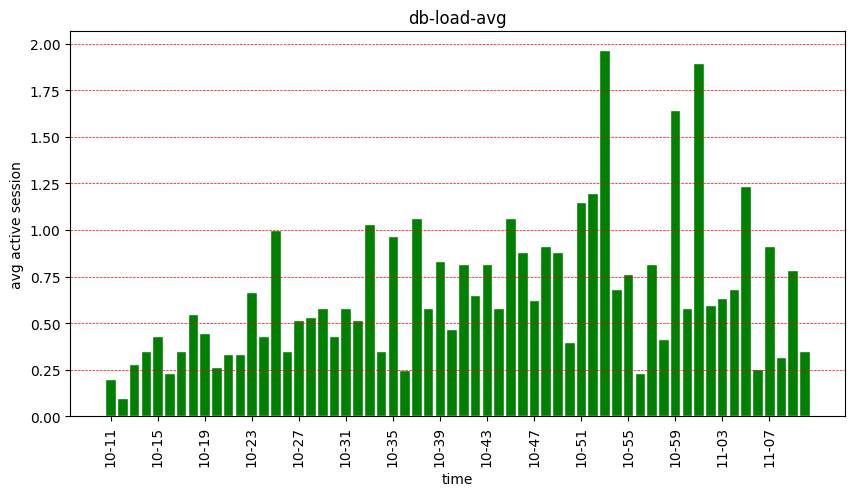

In [61]:
# database load - average atctive session
fig,axes = plt.subplots(1,1,figsize=(10,5))
# axes.plot(db_load_avg_times, db_load_avg_values, label='Average Load')
axes.bar(xtimes, db_load_avg_values, width=0.9, align='center', color='green', edgecolor="white", label='Average Load')
axes.set_xticks(xtimes[::4])
axes.set_title("db-load-avg")
axes.set_ylabel("avg active session")
axes.set_xlabel("time")
axes.grid(axis='y', linestyle='--', linewidth=0.5, color='red')
plt.xticks(rotation=90);

In [85]:
db_load_avg_by_cpu = metric_by_dimension[5]["values"]
db_load_avg_by_lock = metric_by_dimension[9]["values"]
title = metric_by_dimension[5]["name"]

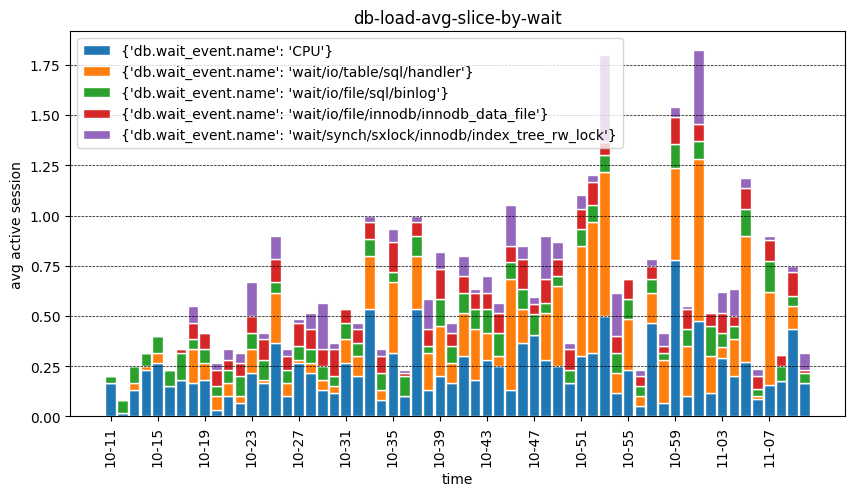

In [101]:
legends = []
bottom = [0.0 for x in range(len(xtimes))]
# database load - average atctive session
fig,axes = plt.subplots(1,1,figsize=(10,5))
# axes.plot(db_load_avg_times, db_load_avg_values, label='Average Load')
for k in range(5,10):
  loads = metric_by_dimension[k]["values"]
  legends.append(metric_by_dimension[k]["name"])
  axes.bar(xtimes, loads, bottom=bottom, width=0.9, align='center', edgecolor="white", label='Average Load')
  bottom = [x + y for x, y in zip(bottom, loads)]
  # axes.bar(xtimes, db_load_avg_by_lock, bottom=db_load_avg_by_cpu, width=0.9, align='center', color='orange', edgecolor="white", label='Average Load')
axes.set_xticks(xtimes[::4])
axes.set_title("db-load-avg-slice-by-wait")
axes.set_ylabel("avg active session")
axes.set_xlabel("time")
axes.legend(legends)
axes.grid(axis='y', linestyle='--', linewidth=0.5, color='black')
plt.xticks(rotation=90);

In [62]:
# [x['Key'] for x in response['MetricList']]

In [63]:
def str_encode(string):
    encoded_str = string.encode("ascii","ignore")
    return remove_non_ascii(encoded_str.decode())

def remove_non_ascii(string):
    non_ascii = ascii(string)
    return non_ascii

In [64]:
def get_db_resource_metrics(instance):
    # Build metric query list
    metric_queries = []
    for group in dbSliceGroup:
        # The example specifies the metric of db.load.avg and a GroupBy of the top seven wait events
        # https://docs.aws.amazon.com/AmazonRDS/latest/AuroraUserGuide/USER_PerfInsights.API.html#USER_PerfInsights.API.Examples.CounterMetrics
        
        logger.info('## metrics for group --> %s ', group)
        metric_queries.append(
        {
            "Metric": "db.load.avg", 
            "GroupBy":
                
                { 
                    "Group": group
                }
        }
        )
        
    if not metric_queries:
        return None

    response = pi_client.get_resource_metrics(
                ServiceType='RDS',
                Identifier=instance,
                StartTime= datetime(2024, 9, 1, 10, 10),
                EndTime= datetime(2024, 9, 1, 11, 10),
                PeriodInSeconds=60,
                MetricQueries=metric_queries
            )

    return response

In [65]:
pi_response = get_db_resource_metrics(instance=dbIds[3])

In [66]:
metric_data = []
for metric_response in pi_response['MetricList']: #dataoints and key
    metric_dict = metric_response['Key']  #db.load.avg
    metric_name = metric_dict['Metric']
 
    is_metric_dimensions = False
    formatted_dims = []
    if metric_dict.get('Dimensions'):
        metric_dimensions = metric_response['Key']['Dimensions']  # return a dictionary
        
        for key in metric_dimensions:
            metric_name = key.split(".")[1]
            formatted_dims.append(dict(Name=key, Value=str_encode(metric_dimensions[key])))
            """ if key == "db.sql_tokenized.statement":
                formatted_dims.append(dict(Name=key, Value=str_encode(metric_dimensions[key])))
            else:
                formatted_dims.append(dict(Name=key, Value=str_encode(metric_dimensions[key]))) """

        is_metric_dimensions = True
    else:
        metric_name = metric_name.replace("avg","")


    for datapoint in metric_response['DataPoints']:
        # We don't always have values from an instance
        value = datapoint.get('Value', None)

        if (value !=None):
            if is_metric_dimensions:
                metric_data.append({
                    'MetricName': metric_name,
                    'Dimensions': formatted_dims,
                    'Timestamp': datapoint['Timestamp'],
                    'Value': round(datapoint['Value'], 2)
                })
            else:
                metric_data.append({
                    'MetricName': metric_name,
                    'Timestamp': datapoint['Timestamp'],
                    'Value': round(datapoint['Value'], 2)
                }) 


In [67]:
metric_data

[{'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 11, tzinfo=tzlocal()),
  'Value': 0.2},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 12, tzinfo=tzlocal()),
  'Value': 0.1},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 13, tzinfo=tzlocal()),
  'Value': 0.28},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 14, tzinfo=tzlocal()),
  'Value': 0.35},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 15, tzinfo=tzlocal()),
  'Value': 0.43},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 16, tzinfo=tzlocal()),
  'Value': 0.23},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 17, tzinfo=tzlocal()),
  'Value': 0.35},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.datetime(2024, 9, 1, 10, 18, tzinfo=tzlocal()),
  'Value': 0.55},
 {'MetricName': 'db.load.',
  'Timestamp': datetime.dateti

In [68]:
# pi_response

In [70]:
[{"name":"hai"}, {"name": "hung"}]

[{'name': 'hai'}, {'name': 'hung'}]